In [1]:
from sklearn.cluster import KMeans

In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np

In [3]:
x, y = make_blobs(n_samples=1000, centers=3, n_features=2, random_state=23)

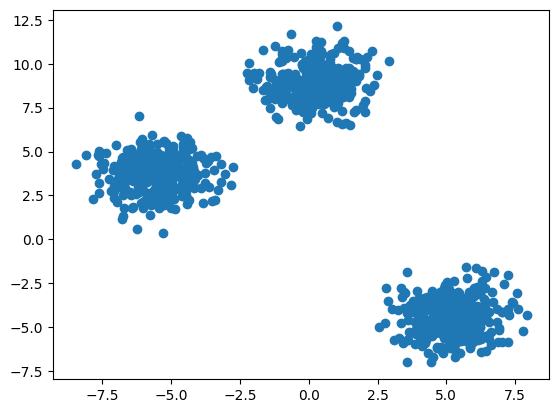

In [4]:
plt.scatter(x[:,0],x[:,1])

In [5]:
kmeans = KMeans(n_clusters= 3, random_state= 42)

In [6]:
kmeans.fit(x)

KMeans(n_clusters=3, random_state=42)

In [7]:
kmeans_label = kmeans.predict(x)

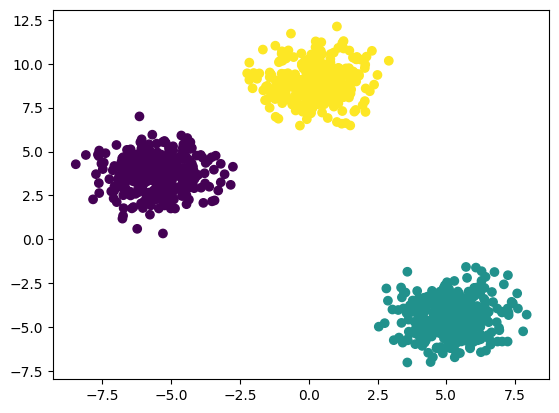

In [8]:
plt.scatter(x[:,0],x[:,1], c = kmeans_label)

In [20]:
wcss = []
k_value = range(2,21)
for k in k_value:
    kmeans = KMeans(n_clusters= k, random_state= 42)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)

In [21]:
wcss

[12017.096385908872,
 1978.419762413036,
 1771.1460915784992,
 1518.4894892585348,
 1303.3491645160843,
 1171.3806440012368,
 1019.4406251883814,
 878.0021319166169,
 810.9973234283317,
 749.7684676598254,
 712.3089871648817,
 652.5973612459761,
 618.8887183157383,
 588.5151733798871,
 554.2632000461731,
 511.11017965207486,
 474.8069923749217,
 463.54681629781766,
 448.27594944482826]

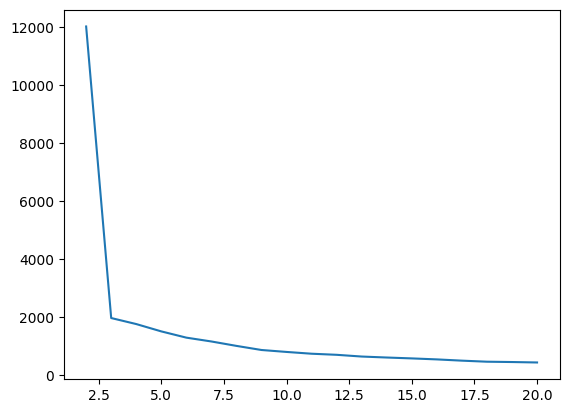

In [22]:
plt.plot(k_value, wcss)

In [23]:
pip install kneed

Note: you may need to restart the kernel to use updated packages.


In [25]:
from kneed import KneeLocator

k1 = KneeLocator(range(2,21),wcss,curve = 'convex',direction='decreasing')
k1.elbow

np.int64(3)

In [13]:
from sklearn.metrics import silhouette_score

In [14]:
silhoette = []
for k in range(2,21):
    kmeans = KMeans(n_clusters= k, random_state= 42)
    kmeans.fit(x)
    kmean_pred = kmeans.predict(x)
    silhoette.append(silhouette_score(x,kmean_pred))

In [15]:
silhoette

[np.float64(0.7243367650317767),
 np.float64(0.8054287074841491),
 np.float64(0.6387923379050701),
 np.float64(0.4670489237606746),
 np.float64(0.32625026423958203),
 np.float64(0.3315070256507883),
 np.float64(0.33781634616989226),
 np.float64(0.34357170585571906),
 np.float64(0.33702121104646154),
 np.float64(0.32889897088271824),
 np.float64(0.32785699373817934),
 np.float64(0.3262951679892455),
 np.float64(0.3285126629495297),
 np.float64(0.3225058701937846),
 np.float64(0.32642867936095926),
 np.float64(0.3266695672680255),
 np.float64(0.3294456142402148),
 np.float64(0.32263111758019436),
 np.float64(0.3178201199448949)]

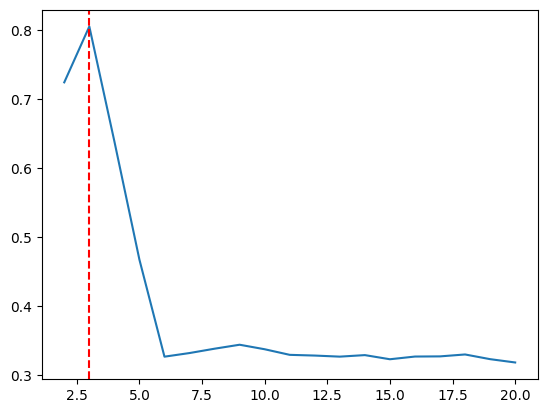

In [16]:
plt.plot(range(2,21),silhoette)
plt.axvline(3, c = 'r', linestyle = '--')

In [17]:
kmeans = KMeans(n_clusters= 3, random_state= 42)
kmeans.fit(x)
kmean_predc= kmeans.predict(x)

In [18]:
silhouette_score(x, kmean_predc)

np.float64(0.8054287074841491)